# 6 · The objects interface (`seaborn.objects`)

**A different API.** The functions in notebooks 1–5 each draw one kind of chart.
`seaborn.objects` instead lets you *compose* a plot from parts on a single
`so.Plot`:

- a **Mark** — what to draw (`Dot`, `Line`, `Bar`, `Bars`, `Area`, `Band`, `Dots`, `Text`, …)
- an optional **Stat** — how to transform the data first (`Agg`, `Est`, `Hist`, `PolyFit`, …)
- an optional **Move** — how to adjust position (`Dodge`, `Jitter`, `Stack`, …)

added with `.add(mark, stat, move)`, plus `.facet()`, `.pair()`, `.scale()`,
`.label()`. The ten cells below rebuild charts you already know from these parts.

## Compositions

| # | Composition | Rebuilds |
|---|---|---|
| 1 | `so.Dot` | a scatter |
| 2 | `so.Line` + `so.Agg` | an aggregated trend line |
| 3 | `so.Bar` + `so.Agg` + `so.Dodge` | grouped bars |
| 4 | `so.Line` + `so.Band` + `so.Est` | a line with a confidence band |
| 5 | `so.Dots` + `so.Jitter` | a strip plot |
| 6 | `so.Bars` + `so.Hist` | a histogram |
| 7 | `so.Dots` + (`so.Line` + `so.PolyFit`) | a regression fit over raw points |
| 8 | `so.Area` + `so.Agg` + `so.Stack` | a stacked area chart |
| 9 | `.facet(col=…)` | small multiples |
| 10 | `.pair(…)` and `so.Text` | a scatter matrix; labelled points |

**Method:** one minimal composition per row; each ends with
`.save("images/6_*.png")`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import seaborn.objects as so

from load_data import load_data

# The objects interface has its own theme; point it at the same house style.
so.Plot.config.theme.update(sns.axes_style("whitegrid"))

penguins = sns.load_dataset("penguins")
fmri = sns.load_dataset("fmri")
healthexp = sns.load_dataset("healthexp")
housing = load_data("california_housing")
sp500 = load_data("sp500")

## 1 · `so.Dot` — a scatter

The mark on its own, no stat: one dot per row.

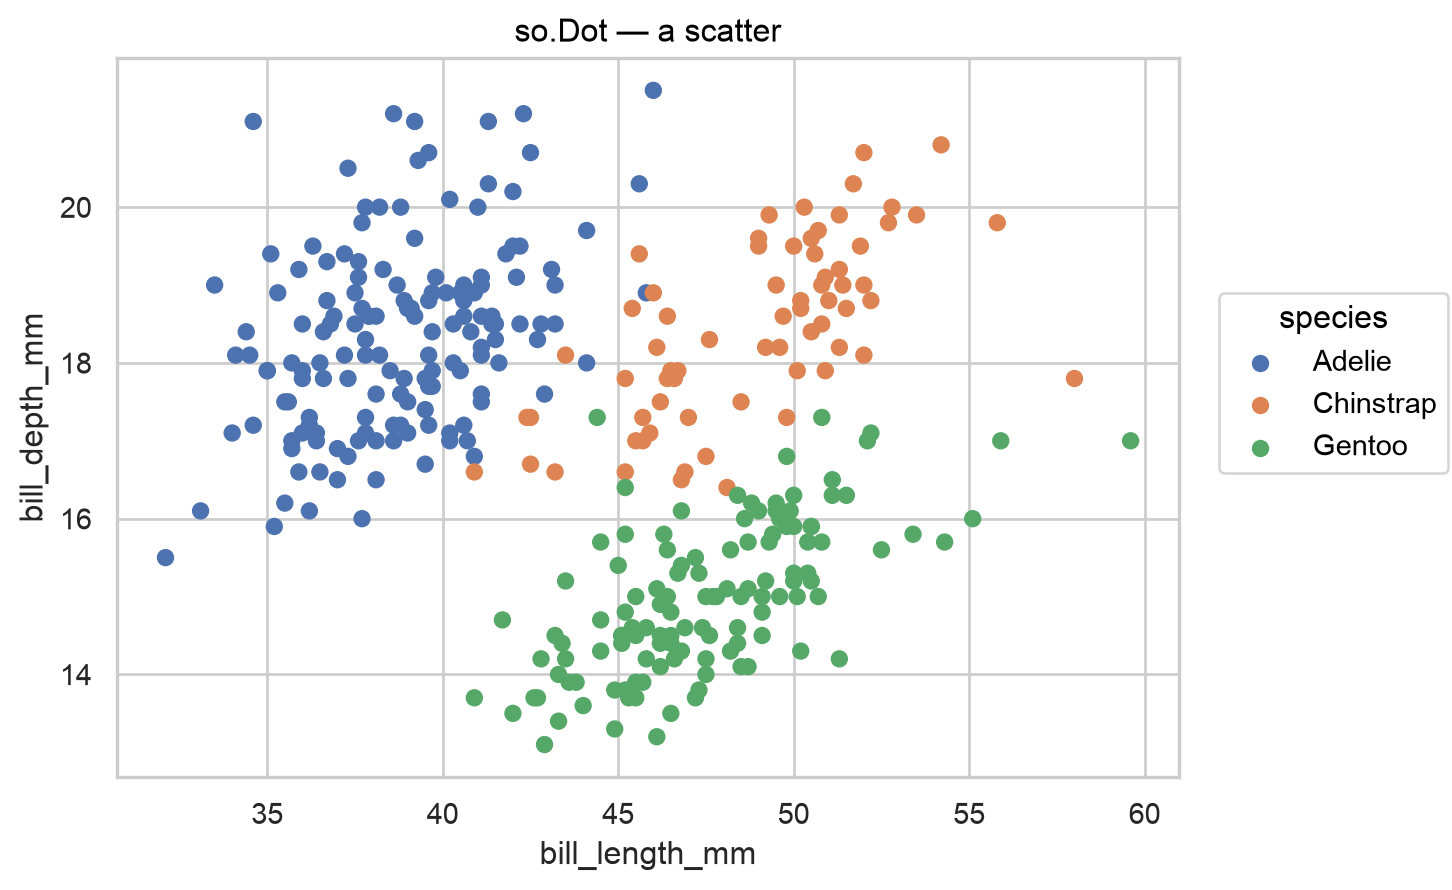

In [2]:
(
    so.Plot(penguins, x="bill_length_mm", y="bill_depth_mm", color="species")
    .add(so.Dot())
    .label(title="so.Dot — a scatter")
    .save("images/6_01_dot.png", dpi=150, bbox_inches="tight")
)

## 2 · `so.Line` + `so.Agg` — an aggregated trend line

`Agg` collapses the many `close` values on each date to their mean, then `Line` connects them — a whole-market average.

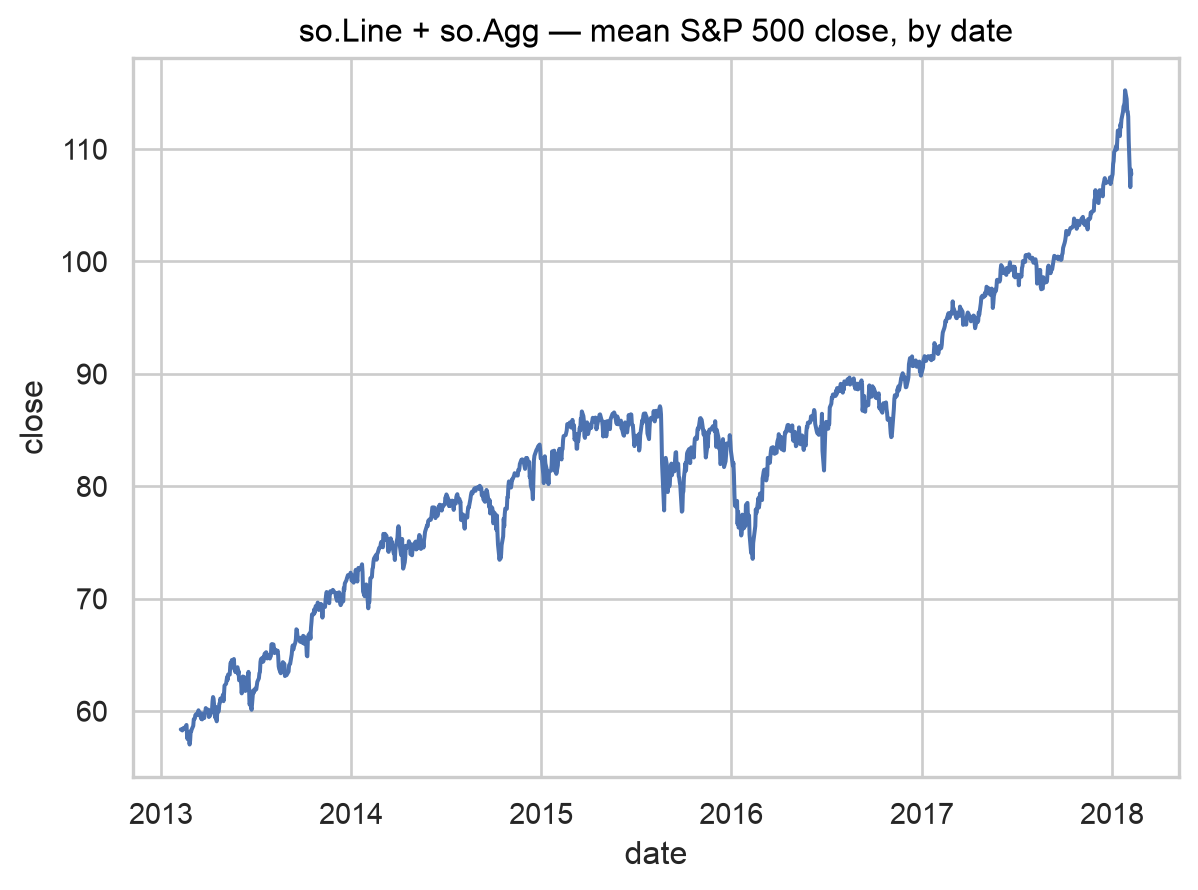

In [3]:
(
    so.Plot(sp500, x="date", y="close")
    .add(so.Line(), so.Agg())
    .label(title="so.Line + so.Agg — mean S&P 500 close, by date")
    .save("images/6_02_line_agg.png", dpi=150, bbox_inches="tight")
)

## 3 · `so.Bar` + `so.Agg` + `so.Dodge` — grouped bars

`Agg` gives the mean per group, `Dodge` moves the `sex` bars side by side.

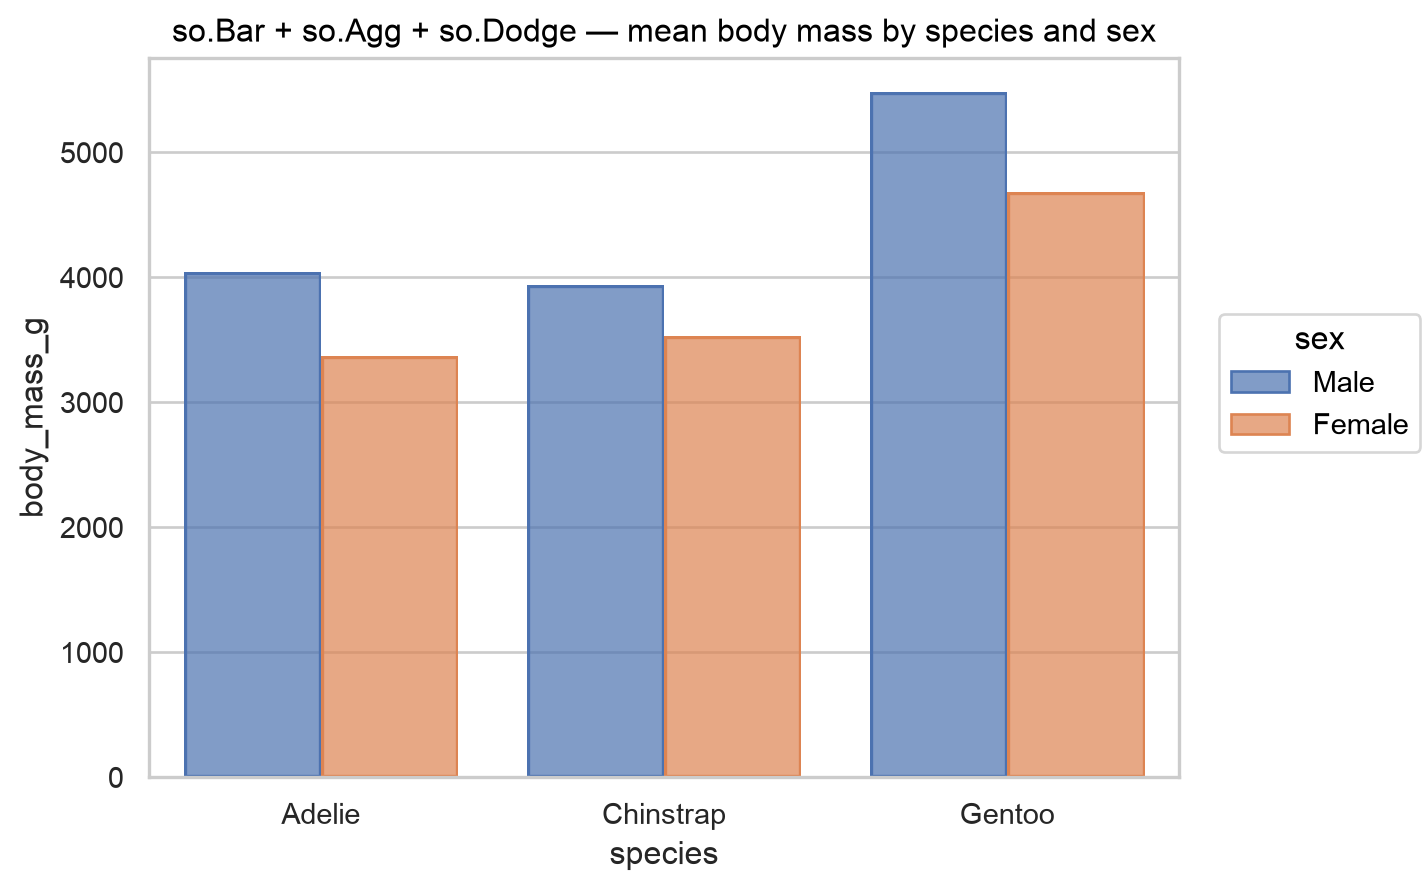

In [4]:
(
    so.Plot(penguins, x="species", y="body_mass_g", color="sex")
    .add(so.Bar(), so.Agg(), so.Dodge())
    .label(title="so.Bar + so.Agg + so.Dodge — mean body mass by species and sex")
    .save("images/6_03_bar_agg_dodge.png", dpi=150, bbox_inches="tight")
)

## 4 · `so.Line` + `so.Band` + `so.Est` — a line with a confidence band

`Est` computes the mean and a 95% CI; one layer draws the line at the mean, the other fills the band.

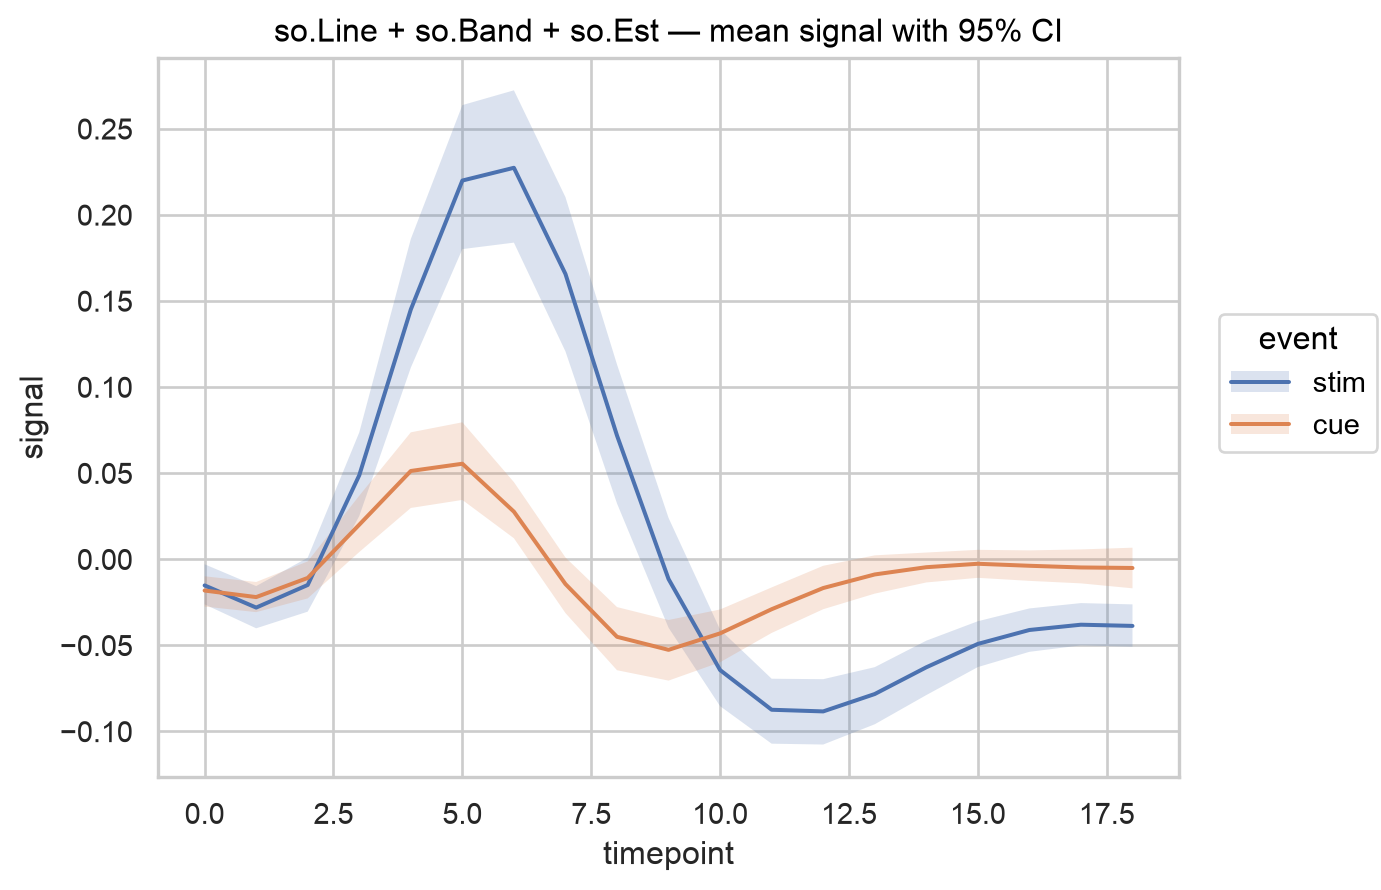

In [5]:
(
    so.Plot(fmri, x="timepoint", y="signal", color="event")
    .add(so.Line(), so.Est())
    .add(so.Band(), so.Est())
    .label(title="so.Line + so.Band + so.Est — mean signal with 95% CI")
    .save("images/6_04_line_band_est.png", dpi=150, bbox_inches="tight")
)

## 5 · `so.Dots` + `so.Jitter` — a strip plot

`Jitter` is a Move: it offsets the dots along the category axis so they don't sit on top of each other.

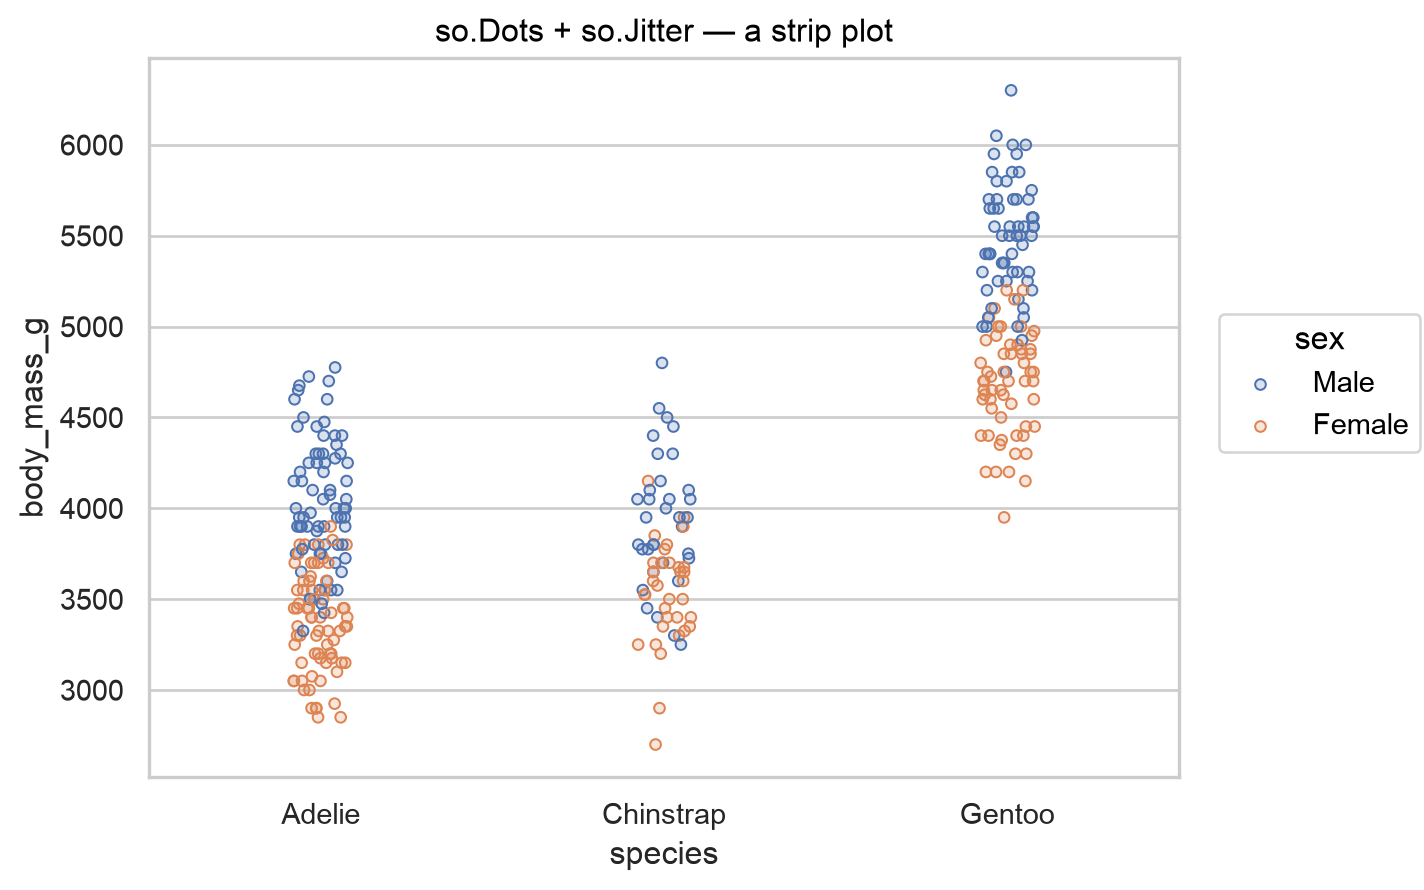

In [6]:
(
    so.Plot(penguins, x="species", y="body_mass_g", color="sex")
    .add(so.Dots(), so.Jitter())
    .label(title="so.Dots + so.Jitter — a strip plot")
    .save("images/6_05_dots_jitter.png", dpi=150, bbox_inches="tight")
)

## 6 · `so.Bars` + `so.Hist` — a histogram

`Hist` is a Stat: it bins `x` and counts. `Bars` (plural) draws the contiguous bars; `Bar` is for a handful of categorical bars.

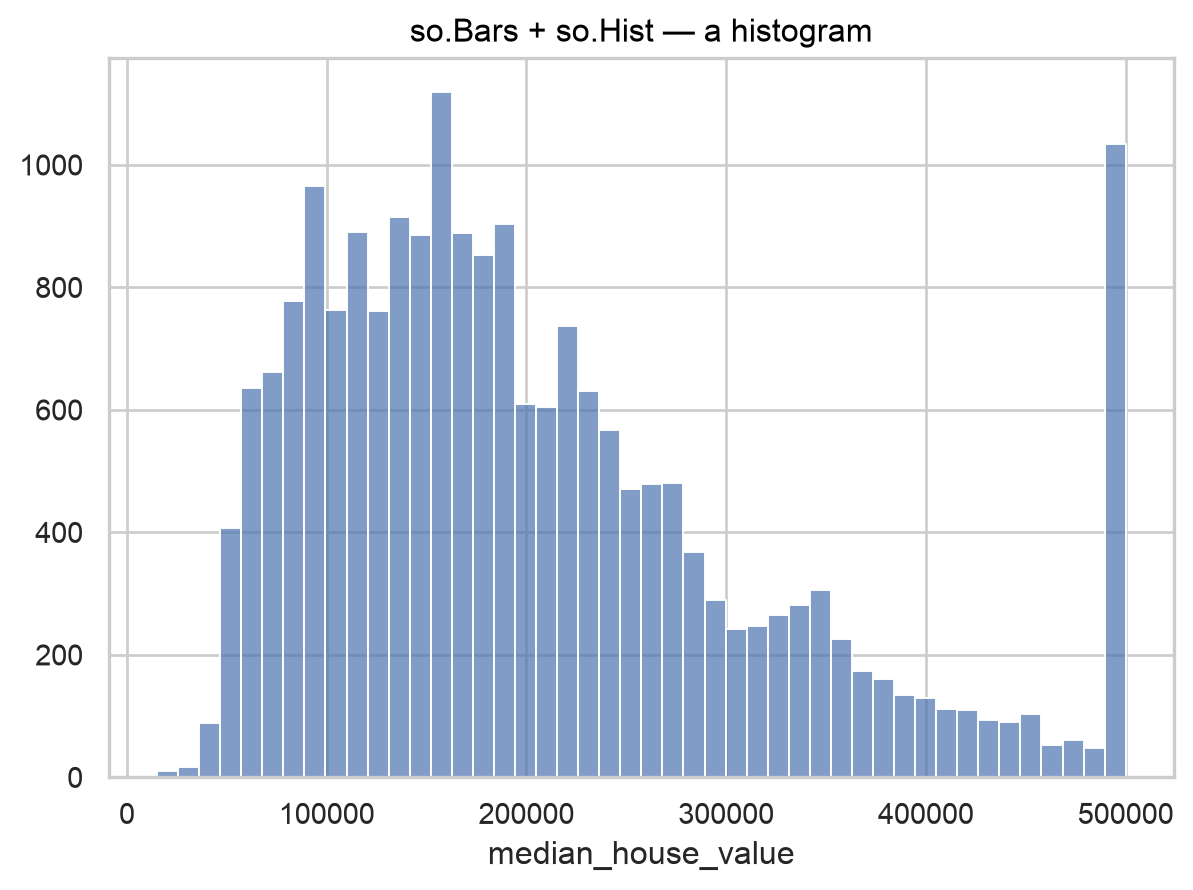

In [7]:
(
    so.Plot(housing, x="median_house_value")
    .add(so.Bars(), so.Hist())
    .label(title="so.Bars + so.Hist — a histogram")
    .save("images/6_06_bars_hist.png", dpi=150, bbox_inches="tight")
)

## 7 · `so.Dots` + (`so.Line` + `so.PolyFit`) — a fit over raw points

Two layers on one plot: the raw scatter, then a degree-2 polynomial fit. Layering like this is where the grammar shines.

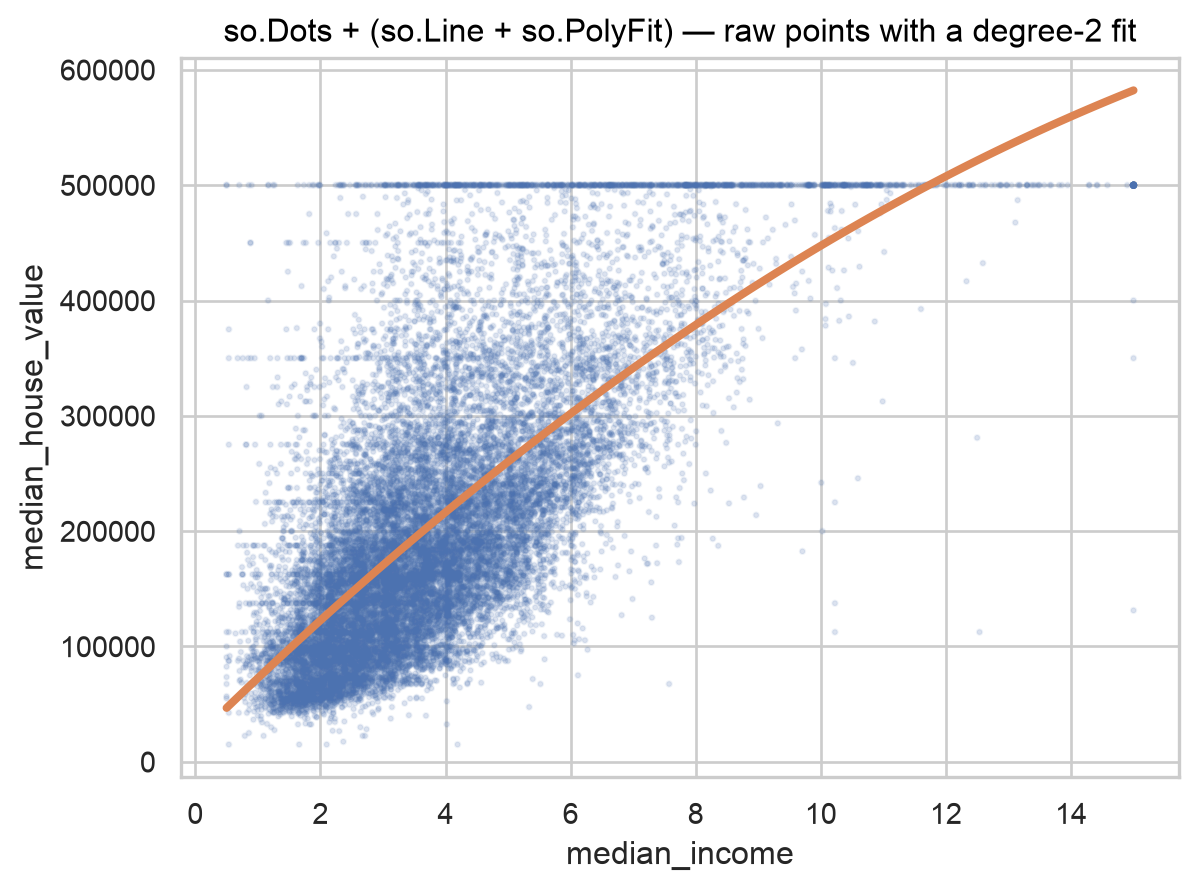

In [8]:
(
    so.Plot(housing, x="median_income", y="median_house_value")
    .add(so.Dots(alpha=.08, pointsize=2))
    .add(so.Line(color="C1", linewidth=3), so.PolyFit(order=2))
    .label(title="so.Dots + (so.Line + so.PolyFit) — raw points with a degree-2 fit")
    .save("images/6_07_polyfit.png", dpi=150, bbox_inches="tight")
)

## 8 · `so.Area` + `so.Agg` + `so.Stack` — a stacked area chart

`Stack` is a Move: it piles each country's area on top of the previous one, so the top edge is the total.

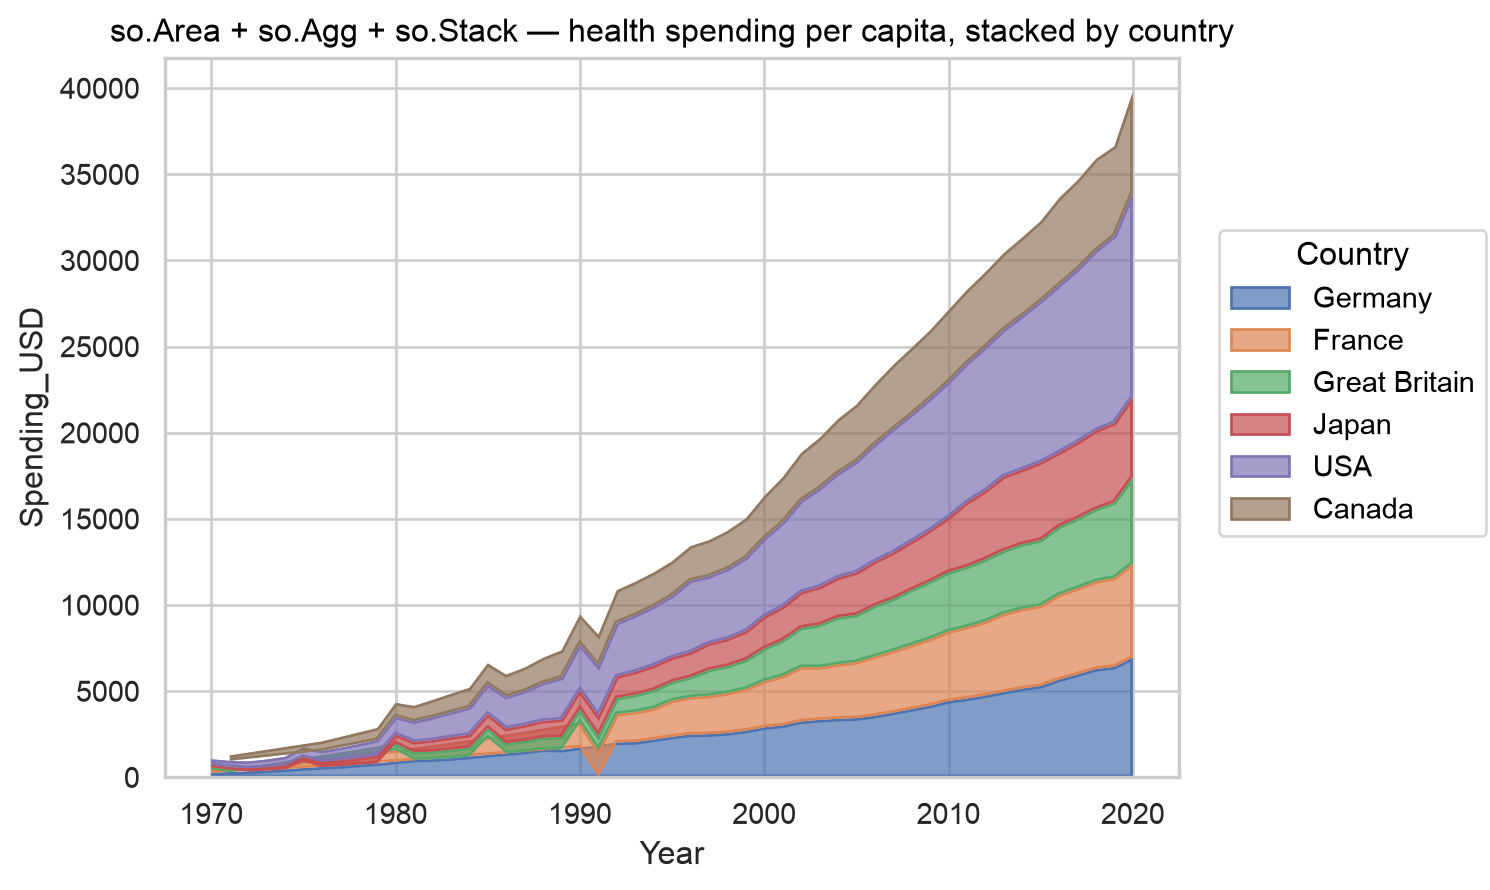

In [9]:
(
    so.Plot(healthexp, x="Year", y="Spending_USD", color="Country")
    .add(so.Area(alpha=.7), so.Agg(), so.Stack())
    .label(title="so.Area + so.Agg + so.Stack — health spending per capita, stacked by country")
    .save("images/6_08_area_stack.png", dpi=150, bbox_inches="tight")
)

## 9 · `.facet(col=…)` — small multiples

Faceting is a method on `Plot`, not a separate object — one call splits the same layers across panels, one per island. (A string `title` would repeat in every panel, so the facet variable's values serve as the panel headers.)

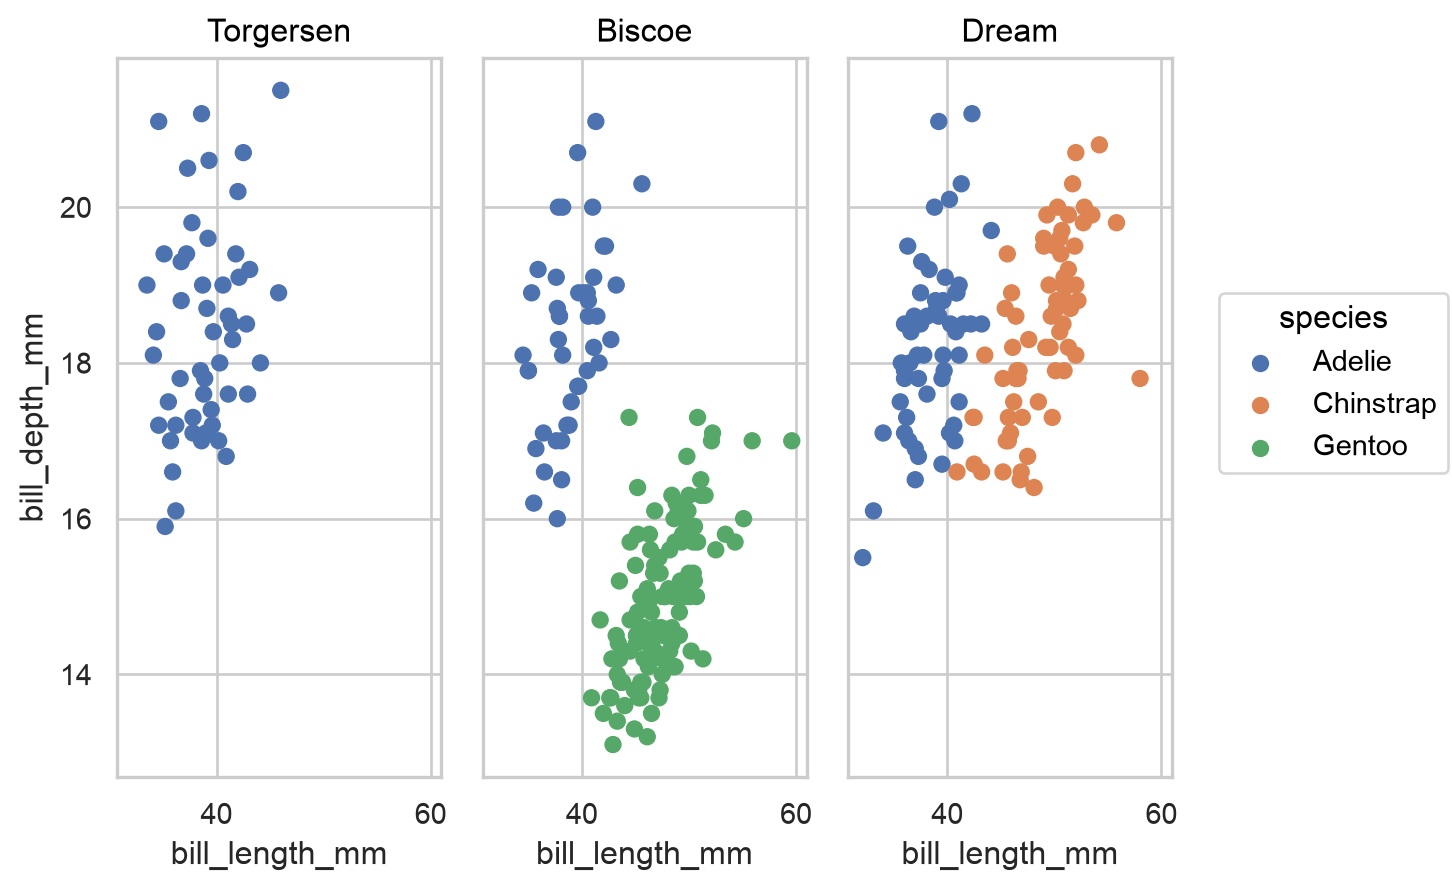

In [10]:
(
    so.Plot(penguins, x="bill_length_mm", y="bill_depth_mm", color="species")
    .add(so.Dot())
    .facet(col="island")
    .save("images/6_09_facet.png", dpi=150, bbox_inches="tight")
)

## 10 · `.pair(…)` and `so.Text`

`.pair()` builds a scatter-matrix-style grid from lists of variables. `so.Text` is a mark that draws a label at each point (from a `text=` channel).

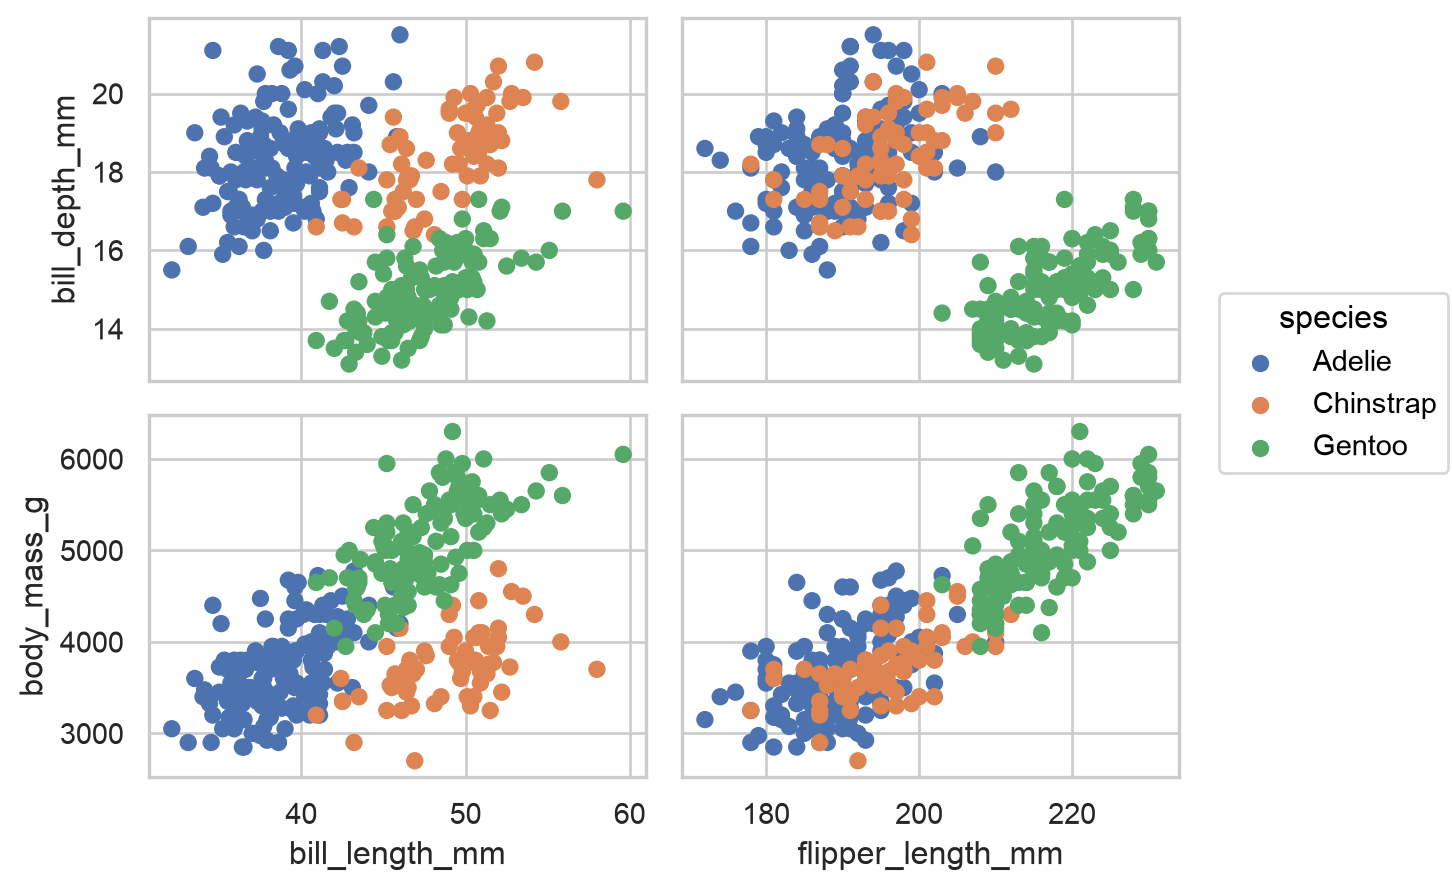

In [11]:
# .pair() builds the grid; like .facet(), a string title would repeat per panel.
(
    so.Plot(penguins, color="species")
    .pair(x=["bill_length_mm", "flipper_length_mm"], y=["bill_depth_mm", "body_mass_g"])
    .add(so.Dot())
    .save("images/6_10_pair.png", dpi=150, bbox_inches="tight")
)

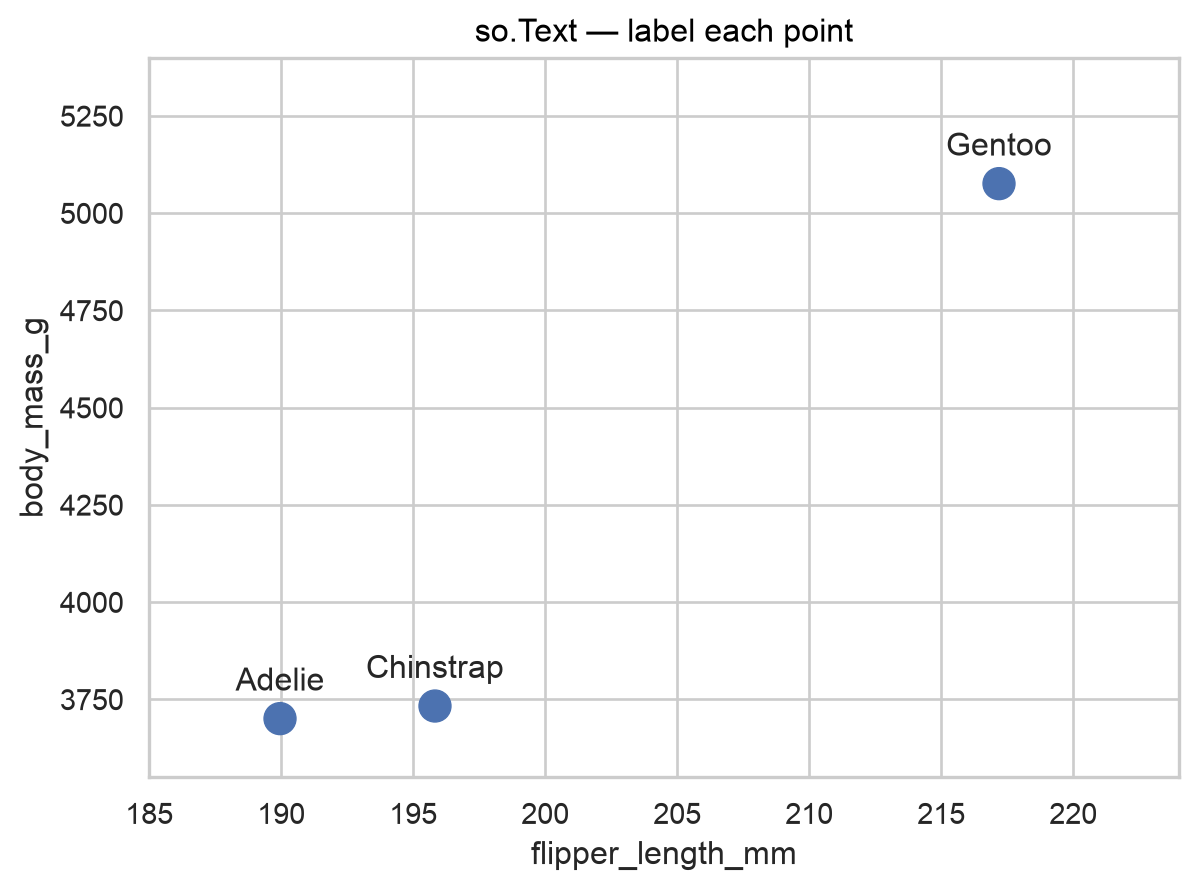

In [12]:
species_means = (
    penguins.groupby("species", as_index=False)[["flipper_length_mm", "body_mass_g"]].mean()
)
(
    so.Plot(species_means, x="flipper_length_mm", y="body_mass_g", text="species")
    .add(so.Dot(pointsize=12))
    .add(so.Text(valign="bottom", offset=8))
    .limit(x=(185, 224), y=(3550, 5400))
    .label(title="so.Text — label each point")
    .save("images/6_10_text.png", dpi=150, bbox_inches="tight")
)

## When to reach for the objects interface

**Use it when:**

- You're **layering** several things on one plot (raw points + a fit, a line + its
  band, bars + labels) — `.add()` stacks cleanly, where the classic API needs
  several functions that don't always agree on defaults.
- You want **one consistent syntax** for everything: the same `Plot` /
  `.add()` / `.facet()` / `.pair()` / `.scale()` grammar covers scatter, line,
  bar, area, histogram… no separate `scatterplot` / `lineplot` / `barplot`
  signatures to remember.
- You want to **swap a Stat or Move without changing the Mark** — `so.Bar()`
  with `so.Hist()` is a histogram, with `so.Agg()` a bar chart.

**Stick with the classic functions when:**

- You need something the objects interface doesn't have yet — `PairGrid`-style
  per-region control, `clustermap`, `jointplot`'s marginal axes, `regplot`'s
  bootstrap CI.
- You're leaning on the large body of examples and Stack Overflow answers written
  for the function API.
- You want a finished styled figure in one line — the classic figure-level
  functions still do more out of the box.

The two APIs share the same theme and colour system and can be mixed in the same
notebook.